In [15]:
import cv2
import os

video_path = "road.mov"
output_folder = "frames"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)

frame_count = 0
save_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        print("Exiting.....")
        break

    if frame_count % 5 == 0:
        frame_name = f"frame_{save_count}.jpg"
        cv2.imwrite(os.path.join(output_folder, frame_name), frame)
        save_count += 1

    frame_count += 1

cap.release()
print("Frames count:", frame_count)
print("Frames saved:", save_count)
print("Original FPS:",fps)

Exiting.....
Frames count: 900
Frames saved: 180
Original FPS: 29.995000833194467


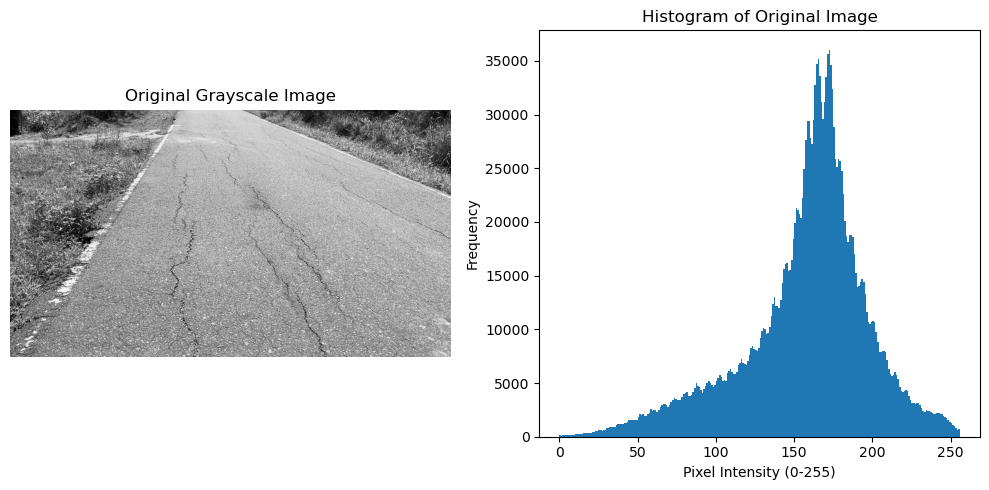

In [16]:
import cv2
import matplotlib.pyplot as plt

image_path = "frames/frame_0.jpg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image not found")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(g.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Original Image")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")



plt.tight_layout()
plt.show()

Image Loaded Successfully
Estimated Noise Mean: 3.8097995e-05
Estimated Noise Standard Deviation: 22.441914


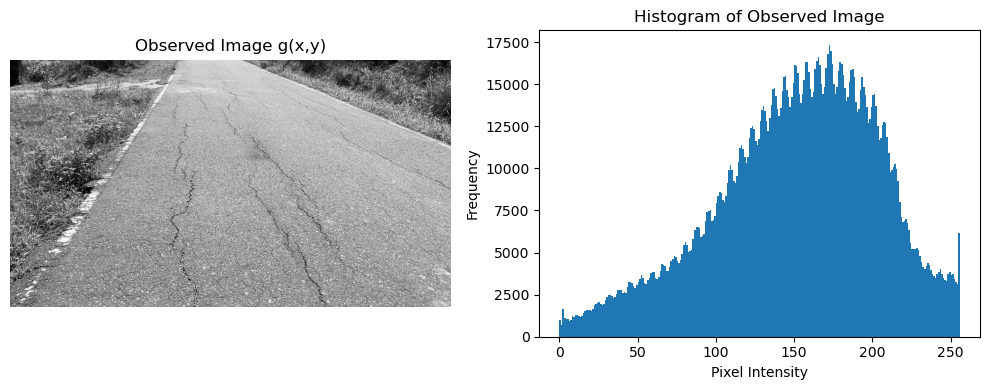

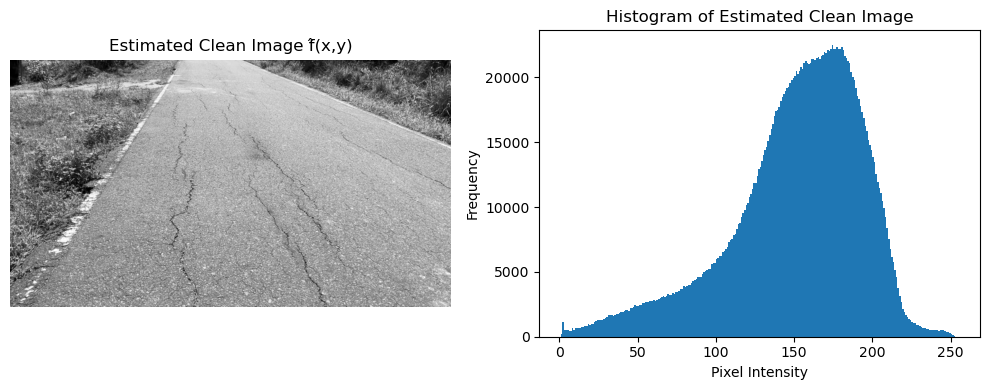

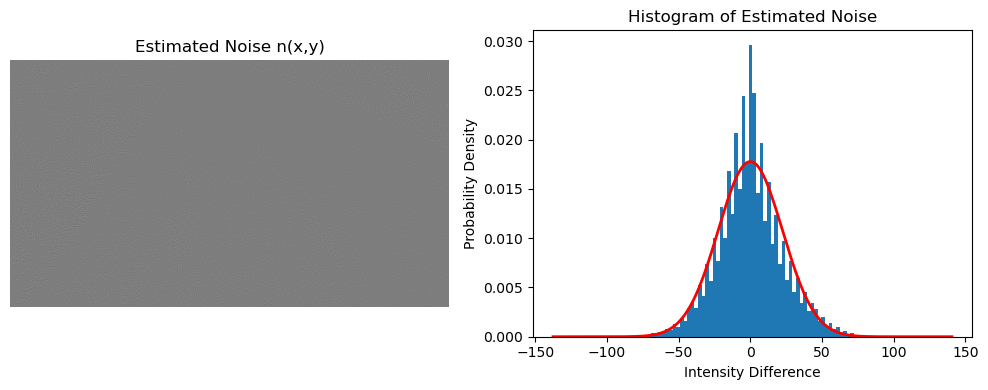

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = "frames/frame_0.jpg"

g = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if g is None:
    print("Error loading image. Check path.")
    exit()

print("Image Loaded Successfully")

# Gaussian Blur
f_hat = cv2.GaussianBlur(g, (5,5), 1)

# Estimate noise
n_est = g.astype(np.float32) - f_hat.astype(np.float32)

noise_mean = np.mean(n_est)
noise_std  = np.std(n_est)

print("Estimated Noise Mean:", noise_mean)
print("Estimated Noise Standard Deviation:", noise_std)

# ==============================
# Observed Image + Histogram
# ==============================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(g, cmap='gray')
plt.title("Observed Image g(x,y)")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(g.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Observed Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ==============================
# Estimated Clean Image + Histogram
# ==============================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(f_hat, cmap='gray')
plt.title("Estimated Clean Image f̂(x,y)")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(f_hat.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Estimated Clean Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ==============================
# Estimated Noise + Histogram
# ==============================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(n_est, cmap='gray')
plt.title("Estimated Noise n(x,y)")
plt.axis('off')

plt.subplot(1,2,2)

# Histogram
plt.hist(n_est.ravel(), bins=100, density=True)
plt.title("Histogram of Estimated Noise")
plt.xlabel("Intensity Difference")
plt.ylabel("Probability Density")

# 🔹 Manual Gaussian Curve (No scipy)
mean = noise_mean
std  = noise_std

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)

# Gaussian PDF formula
p = (1/(std*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2)

plt.plot(x, p, 'r', linewidth=2)

plt.tight_layout()
plt.show()

In [3]:
import cv2
import numpy as np
import os

# -------------------------------
# Folder Path
# -------------------------------
folder_path = "frames"
max_frames = 30

files = sorted(os.listdir(folder_path))

count = 0
mean_list = []
std_list = []

print("Processing frames using Gaussian Filter...\n")

for file in files:
    if file.lower().endswith((".jpg", ".png", ".jpeg")):

        image_path = os.path.join(folder_path, file)
        g = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if g is None:
            continue

        # ✅ Estimated clean image using Gaussian Filter
        f_hat = cv2.GaussianBlur(g, (5, 5), 1)   # sigma=1 (you can try 0 too)

        # Estimate noise
        n_est = g.astype(np.float32) - f_hat.astype(np.float32)

        noise_mean = np.mean(n_est)
        noise_std  = np.std(n_est)

        mean_list.append(noise_mean)
        std_list.append(noise_std)

        print(f"{file} | Mean: {noise_mean:.4f} | Std: {noise_std:.4f}")

        count += 1
        if count == max_frames:
            break

# -------------------------------
# Overall Statistics
# -------------------------------
print("\n============================")
print("Total Frames Processed:", count)
print("Average Noise Mean:", np.mean(mean_list))
print("Average Noise Std Dev:", np.mean(std_list))
print("============================")

Processing frames using Gaussian Filter...

frame_0.jpg | Mean: 0.0000 | Std: 22.4419
frame_1.jpg | Mean: -0.0005 | Std: 21.3220
frame_10.jpg | Mean: -0.0002 | Std: 19.6221
frame_100.jpg | Mean: 0.0011 | Std: 17.9137
frame_101.jpg | Mean: -0.0008 | Std: 18.5319
frame_102.jpg | Mean: -0.0004 | Std: 18.9832
frame_103.jpg | Mean: -0.0010 | Std: 19.1807
frame_104.jpg | Mean: -0.0005 | Std: 18.7000
frame_105.jpg | Mean: -0.0009 | Std: 18.7702
frame_106.jpg | Mean: -0.0000 | Std: 18.8233
frame_107.jpg | Mean: 0.0005 | Std: 18.2575
frame_108.jpg | Mean: -0.0005 | Std: 18.2625
frame_109.jpg | Mean: 0.0000 | Std: 18.4027
frame_11.jpg | Mean: -0.0006 | Std: 19.3280
frame_110.jpg | Mean: -0.0007 | Std: 18.7354
frame_111.jpg | Mean: 0.0001 | Std: 18.4821
frame_112.jpg | Mean: 0.0004 | Std: 18.5922
frame_113.jpg | Mean: 0.0006 | Std: 18.7433
frame_114.jpg | Mean: 0.0007 | Std: 18.8224
frame_115.jpg | Mean: 0.0010 | Std: 18.8507
frame_116.jpg | Mean: 0.0000 | Std: 19.3821
frame_117.jpg | Mean: -0.00

In [4]:
import cv2
import numpy as np
import os

input_folder = "frames"
output_folder = "clean_frames"
max_frames = 30

gauss_ksize = (5, 5)
gauss_sigma = 1   # try 0 or 1

os.makedirs(output_folder, exist_ok=True)

files = sorted(os.listdir(input_folder))

count = 0
print("Saving Estimated Clean Images (Gaussian Filter)...\n")

for file in files:
    if file.lower().endswith((".jpg", ".jpeg", ".png")):

        image_path = os.path.join(input_folder, file)
        g = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if g is None:
            continue

        # 🔹 Gaussian Filter instead of Median
        f_hat = cv2.GaussianBlur(g, gauss_ksize, gauss_sigma)

        out_path = os.path.join(output_folder, file)
        cv2.imwrite(out_path, f_hat)

        print(f"Saved: {out_path}")

        count += 1
        if count == max_frames:
            break

print("\n============================")
print("Total Clean Frames Saved:", count)
print("Output Folder:", output_folder)
print("============================")

Saving Estimated Clean Images (Gaussian Filter)...

Saved: clean_frames\frame_0.jpg
Saved: clean_frames\frame_1.jpg
Saved: clean_frames\frame_10.jpg
Saved: clean_frames\frame_100.jpg
Saved: clean_frames\frame_101.jpg
Saved: clean_frames\frame_102.jpg
Saved: clean_frames\frame_103.jpg
Saved: clean_frames\frame_104.jpg
Saved: clean_frames\frame_105.jpg
Saved: clean_frames\frame_106.jpg
Saved: clean_frames\frame_107.jpg
Saved: clean_frames\frame_108.jpg
Saved: clean_frames\frame_109.jpg
Saved: clean_frames\frame_11.jpg
Saved: clean_frames\frame_110.jpg
Saved: clean_frames\frame_111.jpg
Saved: clean_frames\frame_112.jpg
Saved: clean_frames\frame_113.jpg
Saved: clean_frames\frame_114.jpg
Saved: clean_frames\frame_115.jpg
Saved: clean_frames\frame_116.jpg
Saved: clean_frames\frame_117.jpg
Saved: clean_frames\frame_118.jpg
Saved: clean_frames\frame_119.jpg
Saved: clean_frames\frame_12.jpg
Saved: clean_frames\frame_120.jpg
Saved: clean_frames\frame_121.jpg
Saved: clean_frames\frame_122.jpg
Sav

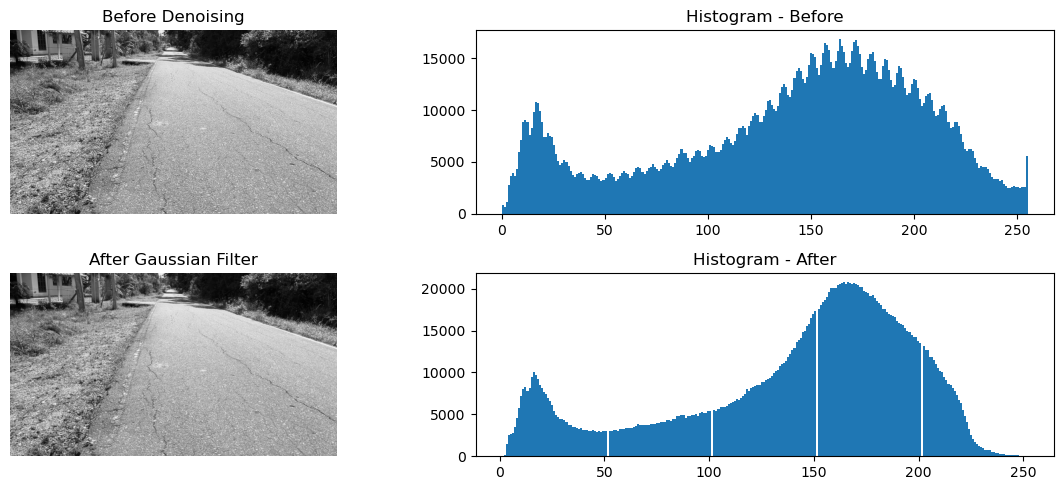

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(g, cmap='gray')
plt.title("Before Denoising")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(g.ravel(), bins=256)
plt.title("Histogram - Before")

plt.subplot(2,2,3)
plt.imshow(f_hat, cmap='gray')
plt.title("After Gaussian Filter")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(f_hat.ravel(), bins=256)
plt.title("Histogram - After")

plt.tight_layout()
plt.show()